<a href="https://colab.research.google.com/github/shahnoorraza/Phishing-URLs-Detection-Using-Deep-Learning-Models/blob/main/bilstm_for_testdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pickle

with open("/content/drive/MyDrive/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [ ]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 639506


In [ ]:
!pip install tensorflow==2.19.0 # Keep the already installed version
!pip install keras>=3.5.0 # Install a compatible Keras version

In [ ]:
pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.6 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import re
import nltk
from nltk.tokenize import RegexpTokenizer
import string
import gensim
from gensim.models import KeyedVectors
from gensim.models import FastText
from wordcloud import WordCloud, STOPWORDS
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Activation, Dropout, Bidirectional, GRU
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, BatchNormalization, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Reshape, Flatten, Concatenate
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from keras.models import model_from_json
import pickle
import json
import logging
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import plot_model
import pandas as pd
import re
import numpy as np

In [ ]:
!pip install wordcloud

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/URL dataset.csv')
df.head(5)

,url,type
0,https://www.google.com,legitimate
1,https://www.youtube.com,legitimate
2,https://www.facebook.com,legitimate
3,https://www.baidu.com,legitimate
4,https://www.wikipedia.org,legitimate


In [ ]:
print(df.columns)

Index(['url', 'type'], dtype='object')


In [ ]:
urldata = df[['url', 'type']]

In [ ]:
duplicates = urldata[urldata.duplicated(subset='url')]
print("Number of duplicate URLs:", duplicates.shape[0])
print(duplicates)

Number of duplicate URLs: 0
Empty DataFrame
Columns: [url, type]
Index: []


In [ ]:
df_no_duplicates_url = urldata.drop_duplicates(subset='url')
print("Shape of DataFrame after removing duplicate URLs:", df_no_duplicates_url.shape)
df_no_duplicates_url.info()
print(df_no_duplicates_url['type'].value_counts())

Shape of DataFrame after removing duplicate URLs: (450176, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450176 entries, 0 to 450175
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     450176 non-null  object
 1   type    450176 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
type
legitimate    345738
phishing      104438
Name: count, dtype: int64


In [ ]:
urldata1= df_no_duplicates_url
urldata1.info()
print(urldata1['type'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450176 entries, 0 to 450175
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     450176 non-null  object
 1   type    450176 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
type
legitimate    345738
phishing      104438
Name: count, dtype: int64


In [ ]:
# Convert labels if needed
urldata1['type'] = urldata1['type'].map({'legitimate':0,'phishing':1})
urldata1.head()

,url,type
0,https://www.google.com,0
1,https://www.youtube.com,0
2,https://www.facebook.com,0
3,https://www.baidu.com,0
4,https://www.wikipedia.org,0


In [ ]:
urldata1['url'] = urldata1['url'].str.lower()
urldata1.head(5)

,url,type
0,https://www.google.com,0
1,https://www.youtube.com,0
2,https://www.facebook.com,0
3,https://www.baidu.com,0
4,https://www.wikipedia.org,0


In [ ]:
urldata1['url'] = urldata1['url'].str.replace(r'^https?:\/\/', '', regex=True)

In [ ]:

# Save the newly generated tokenizer for future use
import pickle
with open("/content/drive/MyDrive/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [ ]:
def tokenize_url(url):
    tokens = re.split(r'([.?/\-_=%&@+;])', url)
    tokens = [token for token in tokens if token.strip()]
    return tokens

In [ ]:
urldata1['text_tokenized'] = urldata1['url'].apply(tokenize_url)

In [ ]:
sequences_test = tokenizer.texts_to_sequences(urldata1['text_tokenized'])

In [ ]:
max_len3 = 66
X_new = pad_sequences(sequences_test,
                      maxlen=max_len3,
                      padding='post',
                      truncating='post')

In [ ]:

y_new = urldata1['type']

In [ ]:
from tensorflow.keras.models import load_model
bilstm_model = load_model('/content/drive/MyDrive/thesis/bigru/bilstm_change_5.h5')

In [ ]:
pred = bilstm_model.predict(X_new)
y_pred1 = (pred > 0.5).astype("int32")


14068/14068 ━━━━━━━━━━━━━━━━━━━━ 116s 8ms/step


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91    345738
           1       0.69      0.74      0.72    104438

    accuracy                           0.86    450176
   macro avg       0.81      0.82      0.81    450176
weighted avg       0.87      0.86      0.87    450176



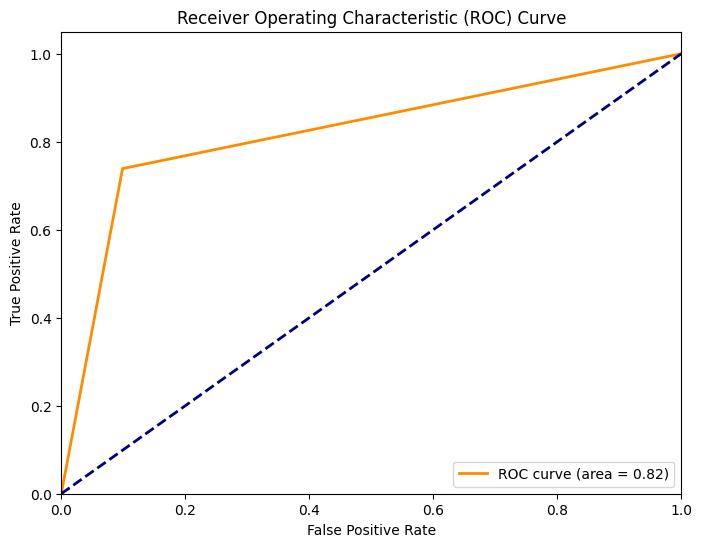

In [ ]:
#Plotting Resulting Graphs





# Classification Report
print("Classification Report:\n", classification_report(y_new, y_pred1))



# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_new, y_pred1)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_new, y_pred1)
print("ROC AUC:", auc)

ROC AUC: 0.8200391607584387


In [ ]:
print(np.mean(pred))
print(np.max(pred))
print(np.min(pred))

0.2717705
0.99994004
0.00021053207


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_new, y_pred1)
print("Accuracy:", accuracy)

Accuracy: 0.8635422590275803
